In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pyhepmc as hp
from particle import Particle

In [7]:
filename = "../CollisionSimulation/electron_proton.hepmc"

In [8]:
with hp.open(filename) as f:
    event = f.read()

event

<GenEvent momentum_unit=1, length_unit=0, event_number=0, particles=76, vertices=46, run_info=GenRunInfo(tools=[], weight_names=['Weight'], attributes={})>

In [9]:
particleEnergies = {}

numFinalStateParticles = 0

with hp.open(filename) as f:
    for event in f:
        print(f"Event number: {event.event_number}")
        print(f"Number of particles: {len(event.particles)}")
        for particle in event.particles:
            # Add particle name and energy to particleEnergies if it's a final state particle
            if particle.status == 1:
                numFinalStateParticles += 1
                name = Particle.from_pdgid(particle.pid).name
                energy = particle.momentum.e
                if name not in particleEnergies:
                    particleEnergies[name] = []
                particleEnergies[name].append(energy)

print(f"Total number of final state particles: {numFinalStateParticles}")

Event number: 0
Number of particles: 76
Event number: 1
Number of particles: 37
Event number: 2
Number of particles: 48
Event number: 3
Number of particles: 144
Event number: 4
Number of particles: 60
Event number: 5
Number of particles: 59
Event number: 6
Number of particles: 86
Event number: 7
Number of particles: 51
Event number: 8
Number of particles: 45
Event number: 9
Number of particles: 38
Event number: 10
Number of particles: 67
Event number: 11
Number of particles: 30
Event number: 12
Number of particles: 77
Event number: 13
Number of particles: 122
Event number: 14
Number of particles: 57
Event number: 15
Number of particles: 55
Event number: 16
Number of particles: 51
Event number: 17
Number of particles: 61
Event number: 18
Number of particles: 61
Event number: 19
Number of particles: 47
Event number: 20
Number of particles: 38
Event number: 21
Number of particles: 56
Event number: 22
Number of particles: 74
Event number: 23
Number of particles: 56
Event number: 24
Number 

In [11]:
particleCounts = {particle: len(energies) for particle, energies in particleEnergies.items()}
particleCounts

{'p': 860,
 'n~': 259,
 'pi-': 4907,
 'pi+': 5303,
 'gamma': 13307,
 'e-': 1095,
 'K-': 482,
 'K+': 539,
 'nu(e)~': 14,
 'n': 708,
 'p~': 309,
 'K(L)0': 533,
 'e+': 93,
 'mu-': 13,
 'mu+': 11,
 'nu(mu)': 10,
 'nu(mu)~': 12,
 'nu(e)': 12,
 'nu(tau)': 3,
 'nu(tau)~': 3}

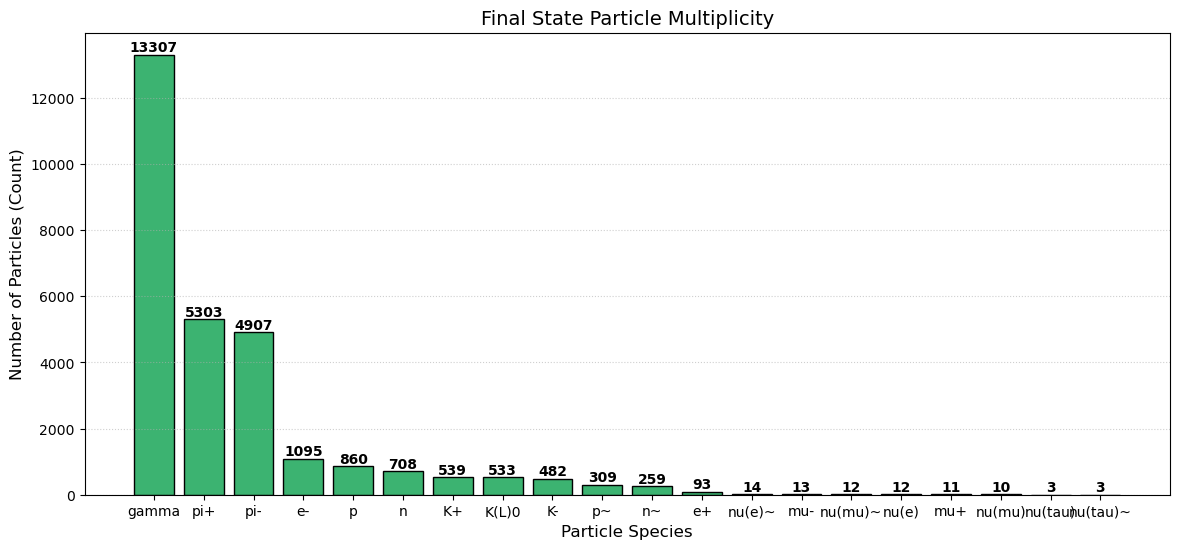

In [13]:
sorted_counts = dict(sorted(particleCounts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(14, 6))
bars = plt.bar(sorted_counts.keys(), sorted_counts.values(), color='mediumseagreen', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom', fontweight='bold')

plt.xlabel('Particle Species', fontsize=12)
plt.ylabel('Number of Particles (Count)', fontsize=12)
plt.title('Final State Particle Multiplicity', fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.6)

In [24]:
sorted(particleEnergies["pi-"])

[0.13975497668875284,
 0.14009411282773965,
 0.14095678171877274,
 0.14588602961557132,
 0.14641221716805677,
 0.147696895585711,
 0.14888693840830594,
 0.1491588236852383,
 0.14944844737410037,
 0.15084979005911767,
 0.1514573412319415,
 0.15149821341691883,
 0.15169201034114785,
 0.15194055480317287,
 0.1528318446197598,
 0.15312957320931095,
 0.15606543632116227,
 0.15678429358649615,
 0.15798675274563195,
 0.15831227276064164,
 0.1590094228910034,
 0.15907651074974635,
 0.15959598786964063,
 0.16134852275254893,
 0.16148249494360392,
 0.16288198642634827,
 0.16463916841958637,
 0.16474475691507456,
 0.16541976269401218,
 0.1661888840330835,
 0.16654102368174484,
 0.16776585497125535,
 0.16778858468524202,
 0.16934994247986312,
 0.1699758663675022,
 0.170628111549908,
 0.17190417402488886,
 0.174007263405214,
 0.17510499525643708,
 0.17614599355010196,
 0.17695016705769376,
 0.17739648203860767,
 0.1793193241082721,
 0.17959826581742303,
 0.18115013164679922,
 0.1826322091967734,
 0

(0.0, 50.0)

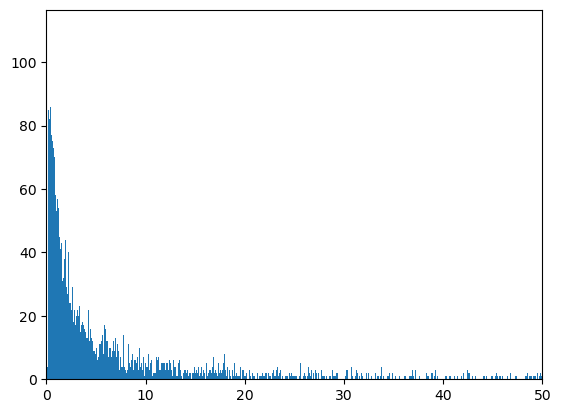

In [23]:
plt.hist(particleEnergies["pi+"], bins=np.linspace(0, 100, 2000))
plt.xlim(0, 50)